In [8]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from spectra.process_absorber_spectrum import read_spectrum_config_json

# Create data

In [2]:
# Source wavelength min and max
absorber_min_wavelength = 320
absorber_max_wavelength = 390

# Wavelength range parameters
range_min_wavelength = 300
range_max_wavelength = 440
num_pnts = (range_max_wavelength - range_min_wavelength) * 2 + 1

absorber_wavelengths = np.linspace(range_min_wavelength, range_max_wavelength, num_pnts)

absorber_absorbance = np.zeros(len(absorber_wavelengths))

absorber_absorbance[np.logical_and(
    absorber_wavelengths >= absorber_min_wavelength, 
    absorber_wavelengths <= absorber_max_wavelength)] = 1

absorber_molar_absorptivity = absorber_absorbance * 1e4 / np.log(10)

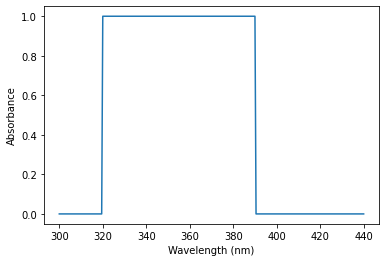

In [3]:
fig, ax = plt.subplots()
ax.plot(absorber_wavelengths, absorber_absorbance)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance');
# plt.savefig('spectrum.png')

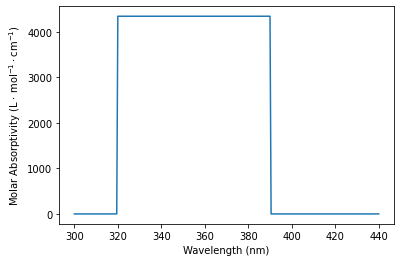

In [4]:
fig, ax = plt.subplots()
ax.plot(absorber_wavelengths, absorber_molar_absorptivity)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Molar Absorptivity (L $\cdot$ mol$^{-1} \cdot$cm$^{-1}$)');
# plt.savefig('spectrum.png')

# Save data to files

In [12]:
header_info = read_spectrum_config_json(Path('spectrum_config.json'))
header_text = json.dumps(header_info)

absorbance = np.stack((absorber_wavelengths, absorber_absorbance)).T
np.savetxt('absorbance.csv', absorbance, delimiter=',', header=header_text)

molar_absorptivity = np.stack((absorber_wavelengths, absorber_molar_absorptivity)).T
np.savetxt('molar_absorptivity.csv', molar_absorptivity, delimiter=',', header=header_text)